# Explainability Analysis for Multimodal Breast Cancer Recurrence Prediction Model

## Overview

This notebook performs the explainability analysis of the developed multimodal Transformer-based survival prediction model for breast cancer recurrence risk prediction.

The trained model integrates three complementary data modalities:

1. **Clinical features**
   - Patient demographic information
   - Tumor characteristics
   - Pathological staging information
   - Treatment-related variables
   - Molecular subtype information

2. **Genomic features**
   - Selected gene expression features used for recurrence risk prediction

3. **Pathology features**
   - Deep feature representations extracted from histopathology image patches

The goal of this notebook is to provide model interpretability by identifying which features, modalities, and pathology regions contribute most to the model predictions.

---

# Explainability Methods Applied

## 1. SHAP-Based Feature Contribution Analysis

SHAP (SHapley Additive exPlanations) was applied separately to each tabular modality to quantify individual feature contributions to the model output.

### Clinical SHAP Analysis

The clinical branch of the model was explained by fixing genomic and pathology inputs while varying clinical features.

Outputs generated:

- Mean absolute SHAP feature importance
- Ranked list of the most influential clinical variables
- SHAP contribution values for individual patients
- Feature importance visualization

This analysis identifies which clinical characteristics have the strongest influence on recurrence risk prediction.

---

### Genomic SHAP Analysis

The genomic branch was explained by fixing clinical and pathology information while varying genomic features.

Outputs generated:

- Mean absolute SHAP importance for genes
- Ranked list of the most influential genes
- Patient-level genomic SHAP contribution values
- Gene importance visualization

This analysis highlights genes that contribute most to the Transformer survival prediction.

---

# 2. Transformer Attention Analysis

The internal attention mechanism of the multimodal Transformer was analyzed to understand how the model combines different modalities.

The attention extraction process evaluates:

- Clinical token attention
- Genomic token attention
- Pathology token attention

Outputs generated:

- Attention matrices from Transformer layers
- Modality-level attention visualization
- Attention heatmaps

This provides insight into how the model prioritizes different information sources during prediction.

---

# 3. Pathology Attention Visualization

The pathology Transformer encoder was analyzed to identify important histopathology image patches.

The attention mechanism assigns importance scores to individual image patches.

Outputs generated:

- Patch-level attention scores
- Ranking of the highest-attention pathology patches
- Top contributing patch table

These results indicate which regions of the histopathology representation receive the highest attention from the model.

---

# Model Explainability Outputs

The following explainability results are saved:

## SHAP Results

- Clinical SHAP feature importance table (.csv)
- Genomic SHAP feature importance table (.csv)
- Patient-level SHAP contribution values
- SHAP visualization figures

## Attention Results

- Transformer attention matrices
- Modality attention visualization
- Pathology patch attention table (.csv)
- Pathology attention figures

All results are stored in the explanation output directory for further analysis and inclusion in the Master's thesis.

---

# Purpose of Explainability Analysis

The explainability analysis demonstrates that the proposed multimodal Transformer model is not only capable of predicting breast cancer recurrence risk but also provides interpretable evidence regarding:

- Which clinical variables influence predictions
- Which genomic features contribute to risk estimation
- How the Transformer combines multimodal information
- Which pathology regions receive higher model attention

These analyses improve model transparency and support the clinical interpretability of the proposed AI framework.

##Imports

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shap

from tqdm import tqdm
from torch.utils.data import DataLoader

##Mount Google Drive

In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


##Define Project Paths

In [ ]:
# ============================================================
# PROJECT PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/TCGA_BRCA"

DATASET_DIR = os.path.join(
    BASE_DIR,
    "rfs_feature_selection"
)

PATHOLOGY_DIR = os.path.join(
    BASE_DIR,
    "Features"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "trained_models"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "transformer_results"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("="*70)
print("Project paths ready.")
print("="*70)

Project paths ready.


##Device Configuration

In [ ]:
# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("="*70)
print("Running on:", DEVICE)
print("="*70)

Running on: cpu


##Load datasets

In [ ]:
# ============================================================
# LOAD DATASETS
# ============================================================

train = pd.read_csv(
    os.path.join(
        DATASET_DIR,
       "rfs_train_selected.csv"
    )
)

validation = pd.read_csv(
    os.path.join(
        DATASET_DIR,
       "rfs_validation_selected.csv"
    )
)

test = pd.read_csv(
    os.path.join(
        DATASET_DIR,
        "rfs_test_selected.csv"
    )
)

print("="*70)
print("DATASETS LOADED")
print("="*70)

print("Train      :", train.shape)
print("Validation :", validation.shape)
print("Test       :", test.shape)

DATASETS LOADED
Train      : (249, 224)
Validation : (54, 224)
Test       : (54, 224)


In [ ]:
print("Train shape:", train.shape)

non_feature_columns = [
    "patient_id",
    "file_uuid",
    "event",
    "survival_time"
]

clinical_columns = [
    "years_to_birth",
    "Tumor_purity",
    "pathologic_stage",
    "pathology_T_stage",
    "pathology_N_stage",
    "pathology_M_stage",
    "number_of_lymph_nodes",
    "radiation_therapy"
]

clinical_columns += [
    c for c in train.columns
    if c.startswith((
        "histological_type",
        "PAM50",
        "race",
        "ethnicity"
    ))
]

genomic_columns = [
    c for c in train.columns
    if c not in clinical_columns + non_feature_columns
]

print("Clinical:", len(clinical_columns))
print("Genomic :", len(genomic_columns))

Train shape: (249, 224)
Clinical: 20
Genomic : 200


##Define Feature Groups

In [ ]:
# ============================================================
# DEFINE FEATURE GROUPS
# ============================================================


non_feature_columns = [
    "patient_id",
    "file_uuid",
    "event",
    "survival_time"
]

clinical_columns = [
    "years_to_birth",
    "Tumor_purity",
    "pathologic_stage",
    "pathology_T_stage",
    "pathology_N_stage",
    "pathology_M_stage",
    "number_of_lymph_nodes",
    "radiation_therapy"
]

clinical_columns += [
    c for c in train.columns
    if c.startswith((
        "histological_type",
        "PAM50",
        "race",
        "ethnicity"
    ))
]

genomic_columns = [
    c for c in train.columns
    if c not in clinical_columns + non_feature_columns
]

target_columns = [
    "event",
    "survival_time"
]

print("="*70)
print("FEATURE GROUPS")
print("="*70)

print("Clinical features:", len(clinical_columns))
print("Genomic features :", len(genomic_columns))

print("\nFirst clinical:")
print(clinical_columns[:5])

print("\nFirst genomic:")
print(genomic_columns[:5])

FEATURE GROUPS
Clinical features: 20
Genomic features : 200

First clinical:
['years_to_birth', 'Tumor_purity', 'pathologic_stage', 'pathology_T_stage', 'pathology_N_stage']

First genomic:
['MYBPC1', 'ZNF385B', 'ALG1L', 'PCDH10', 'FLT3']


##Import PyTorch and create Dataset

In [ ]:
# ============================================================
# MULTIMODAL PYTORCH DATASET
# ============================================================


import torch

from torch.utils.data import Dataset


class MultimodalBreastCancerDataset(Dataset):


    def __init__(
        self,
        dataframe
    ):

        self.data = dataframe.reset_index(drop=True)



    def __len__(self):

        return len(self.data)



    def __getitem__(
        self,
        idx
    ):

        row = self.data.iloc[idx]


        # ----------------------------
        # Clinical features
        # ----------------------------

        clinical = row[
            clinical_columns
        ].values.astype(np.float32)



        # ----------------------------
        # Genomic features
        # ----------------------------

        genomic = row[
            genomic_columns
        ].values.astype(np.float32)



        # ----------------------------
        # Pathology features
        # ----------------------------

        pathology, mask = load_pathology_features(
            row["file_uuid"],
            MAX_PATCHES
        )



        # ----------------------------
        # Labels
        # ----------------------------

        event = np.float32(
            row["event"]
        )


        survival = np.float32(
            row["survival_time"]
        )



        return {

            "clinical":
            torch.tensor(
                clinical
            ),


            "genomic":
            torch.tensor(
                genomic
            ),


            "pathology":
            torch.tensor(
                pathology
            ),


            "mask":
            torch.tensor(
                mask
            ),


            "label":
            torch.tensor(
                event
            ),


            "survival":
            torch.tensor(
                survival
            ),


            "event":
torch.tensor(
    event
)
        }

##Create datasets

In [ ]:
# ============================================================
# CREATE PYTORCH DATASETS
# ============================================================


train_dataset = MultimodalBreastCancerDataset(
    train
)


val_dataset = MultimodalBreastCancerDataset(
    validation
)


test_dataset = MultimodalBreastCancerDataset(
    test
)



print("="*70)

print("Train samples:",
      len(train_dataset))

print("Validation samples:",
      len(val_dataset))

print("Test samples:",
      len(test_dataset))

Train samples: 249
Validation samples: 54
Test samples: 54


##DataLoaders

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


##Model Config

In [ ]:
# ============================================================
# MODEL CONFIGURATION
# ============================================================


MODEL_CONFIG = {


    # feature sizes

    "clinical_dim": len(clinical_columns),

    "genomic_dim": len(genomic_columns),

    "pathology_dim": 512,


    # transformer

    "embed_dim": 128,

    "num_heads": 4,

    "num_layers": 2,


    # regularization

    "dropout": 0.3,


    # training

    "batch_size": 4,

    "learning_rate": 1e-4,

    "epochs": 100

}



print("="*70)
print("MODEL CONFIGURATION")
print("="*70)


for k,v in MODEL_CONFIG.items():

    print(
        k,
        ":",
        v
    )

MODEL CONFIGURATION
clinical_dim : 20
genomic_dim : 200
pathology_dim : 512
embed_dim : 128
num_heads : 4
num_layers : 2
dropout : 0.3
batch_size : 4
learning_rate : 0.0001
epochs : 100


##Clinical Encoder

In [ ]:
# ============================================================
# CLINICAL ENCODER
# ============================================================

import torch
import torch.nn as nn



class ClinicalEncoder(nn.Module):


    def __init__(
        self,
        input_dim,
        embed_dim,
        dropout=0.3
    ):

        super().__init__()


        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                embed_dim
            ),

            nn.LayerNorm(
                embed_dim
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            )

        )



    def forward(
        self,
        x
    ):

        """
        x:
        [batch, clinical_features]

        output:
        [batch, 1, embedding]
        """


        x = self.encoder(x)


        # create token dimension

        x = x.unsqueeze(1)


        return x

##Genomic Encoder

In [ ]:
# ============================================================
# GENOMIC ENCODER
# ============================================================


class GenomicEncoder(nn.Module):


    def __init__(
        self,
        input_dim,
        embed_dim,
        dropout=0.3
    ):

        super().__init__()



        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.LayerNorm(
                256
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),


            nn.Linear(
                256,
                embed_dim
            ),

            nn.LayerNorm(
                embed_dim
            )

        )



    def forward(
        self,
        x
    ):


        x = self.encoder(x)


        x = x.unsqueeze(1)


        return x

##Pathology Transformer Encoder

In [ ]:
# ============================================================
# PATHOLOGY TRANSFORMER ENCODER
# ============================================================


class PathologyEncoder(nn.Module):


    def __init__(
        self,
        input_dim,
        embed_dim,
        num_heads,
        num_layers,
        dropout=0.3
    ):

        super().__init__()


        # project pathology features
        # 512 -> 128

        self.patch_projection = nn.Linear(
            input_dim,
            embed_dim
        )



        # learnable CLS token

        self.cls_token = nn.Parameter(
            torch.randn(
                1,
                1,
                embed_dim
            )
        )



        encoder_layer = nn.TransformerEncoderLayer(

            d_model=embed_dim,

            nhead=num_heads,

            dim_feedforward=embed_dim*4,

            dropout=dropout,

            batch_first=True,

            activation="gelu"

        )


        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=num_layers

        )



        self.norm = nn.LayerNorm(
            embed_dim
        )



    def forward(
        self,
        x,
        mask=None
    ):


        """
        x:

        [batch, patches, 512]


        output:

        [batch,1,128]

        """



        batch_size = x.size(0)



        # project patches

        x = self.patch_projection(x)


        # create CLS token for each patient

        cls_tokens = self.cls_token.expand(
            batch_size,
            -1,
            -1
        )


        x = torch.cat(
            [
                cls_tokens,
                x
            ],
            dim=1
        )



        # transformer attention

        x = self.transformer(
            x
        )



        # take CLS representation

        x = x[:,0,:]


        x = self.norm(x)


        # restore token dimension

        x = x.unsqueeze(1)



        return x

##The Fusion Module

In [ ]:
# ============================================================
# MULTIMODAL FUSION TRANSFORMER
# ============================================================


class MultimodalFusionTransformer(nn.Module):


    def __init__(
        self,
        embed_dim,
        num_heads,
        num_layers,
        dropout=0.3
    ):

        super().__init__()



        encoder_layer = nn.TransformerEncoderLayer(

            d_model=embed_dim,

            nhead=num_heads,

            dim_feedforward=embed_dim*4,

            dropout=dropout,

            batch_first=True,

            activation="gelu"

        )



        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=num_layers

        )



        self.norm = nn.LayerNorm(
            embed_dim
        )



    def forward(
        self,
        clinical_token,
        genomic_token,
        pathology_token
    ):


        """

        Inputs:

        clinical:
        [batch,1,128]


        genomic:
        [batch,1,128]


        pathology:
        [batch,1,128]



        Output:

        fused representation

        [batch,128]

        """



        # concatenate modality tokens

        x = torch.cat(

            [
                clinical_token,
                genomic_token,
                pathology_token
            ],

            dim=1

        )



        # now:

        # [batch,3,128]


        x = self.transformer(
            x
        )


        x = self.norm(x)



        # mean pooling over modalities

        x = x.mean(
            dim=1
        )


        return x

##Prediction Heads

In [ ]:
class SurvivalPredictionHead(nn.Module):

    def __init__(
        self,
        embed_dim,
        dropout=0.3
    ):
        super().__init__()

        self.head = nn.Sequential(

            nn.Linear(
                embed_dim,
                64
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                64,
                1
            )
        )


    def forward(self, x):

        risk = self.head(x)

        return risk

##Create the Complete Model

In [ ]:
# ============================================================
# COMPLETE MULTIMODAL TRANSFORMER
# ============================================================


class MultimodalTransformer(nn.Module):


    def __init__(
        self,
        config
    ):

        super().__init__()



        self.clinical_encoder = ClinicalEncoder(

            config["clinical_dim"],

            config["embed_dim"],

            config["dropout"]

        )



        self.genomic_encoder = GenomicEncoder(

            config["genomic_dim"],

            config["embed_dim"],

            config["dropout"]

        )



        self.pathology_encoder = PathologyEncoder(

            config["pathology_dim"],

            config["embed_dim"],

            config["num_heads"],

            config["num_layers"],

            config["dropout"]

        )



        self.fusion = MultimodalFusionTransformer(

            config["embed_dim"],

            config["num_heads"],

            config["num_layers"],

            config["dropout"]

        )



        self.survival_head = SurvivalPredictionHead(
            config["embed_dim"],
            config["dropout"]
        )




    def forward(
        self,
        clinical,
        genomic,
        pathology,
        mask=None,
        use_modalities=None
    ):


        # ---------------------------------
        # Default: use all modalities
        # ---------------------------------

        if use_modalities is None:

            use_modalities = {

                "clinical": True,

                "genomic": True,

                "pathology": True

            }



        # ---------------------------------
        # Clinical encoder
        # ---------------------------------

        clinical_token = self.clinical_encoder(
            clinical
        )


        if not use_modalities["clinical"]:

            clinical_token = torch.zeros_like(
                clinical_token
            )



        # ---------------------------------
        # Genomic encoder
        # ---------------------------------

        genomic_token = self.genomic_encoder(
            genomic
        )


        if not use_modalities["genomic"]:

            genomic_token = torch.zeros_like(
                genomic_token
            )



        # ---------------------------------
        # Pathology encoder
        # ---------------------------------

        pathology_token = self.pathology_encoder(
            pathology,
            mask
        )


        if not use_modalities["pathology"]:

            pathology_token = torch.zeros_like(
                pathology_token
            )



        # ---------------------------------
        # Fusion Transformer
        # ---------------------------------

        fused = self.fusion(

            clinical_token,

            genomic_token,

            pathology_token

        )



        # ---------------------------------
        # Prediction heads
        # ---------------------------------

        survival = self.survival_head(fused)



        return {


            "survival":
            survival,


            "features":
            fused

        }

In [ ]:
# ============================================================
# CREATE MODEL ARCHITECTURE
# ============================================================

model = MultimodalTransformer(
    MODEL_CONFIG
)

model = model.to(DEVICE)


print("MODEL CREATED")

MODEL CREATED


##Create pathology loading configuration

In [ ]:
# ============================================================
# PATHOLOGY CONFIGURATION
# ============================================================


PATHOLOGY_DIR = "/content/drive/MyDrive/TCGA_BRCA/Features"


MAX_PATCHES = 512
PATCH_FEATURES = 512


print("="*70)
print("PATHOLOGY CONFIGURATION")
print("="*70)

print("Directory:")
print(PATHOLOGY_DIR)

print()

print("Maximum patches per patient:", MAX_PATCHES)
print("Patch embedding dimension:", PATCH_FEATURES)

PATHOLOGY CONFIGURATION
Directory:
/content/drive/MyDrive/TCGA_BRCA/Features

Maximum patches per patient: 512
Patch embedding dimension: 512


##Create pathology processing function

In [ ]:
# ============================================================
# PATHOLOGY PROCESSING FUNCTION
# ============================================================

import numpy as np


def load_pathology_features(
    file_uuid,
    max_patches=512
):

    path = os.path.join(
        PATHOLOGY_DIR,
        file_uuid + ".npy"
    )


    features = np.load(path)



    # -----------------------------------
    # Case 1:
    # More patches than maximum
    # -----------------------------------

    if features.shape[0] > max_patches:

        indices = np.random.choice(
            features.shape[0],
            max_patches,
            replace=False
        )

        features = features[indices]


        mask = np.ones(
            max_patches
        )



    # -----------------------------------
    # Case 2:
    # Fewer patches
    # -----------------------------------

    else:

        current = features.shape[0]


        padding = np.zeros(
            (
                max_patches-current,
                features.shape[1]
            ),
            dtype=np.float32
        )


        features = np.concatenate(
            [
                features,
                padding
            ],
            axis=0
        )


        mask = np.concatenate(
            [
                np.ones(current),
                np.zeros(max_patches-current)
            ]
        )



    return (
        features.astype(np.float32),
        mask.astype(np.float32)
    )

##Load the trained model

In [ ]:
checkpoint_path = "/content/drive/MyDrive/TCGA_BRCA/trained_models/best_transformer_all_Modailates_RFS2.pt"

model = MultimodalTransformer(MODEL_CONFIG)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=DEVICE
    )
)

model = model.to(DEVICE)

model.eval()

print("Model loaded.")

Model loaded.


In [ ]:
batch = next(iter(test_loader))

clinical = batch["clinical"].to(DEVICE)

genomic = batch["genomic"].to(DEVICE)

pathology = batch["pathology"].to(DEVICE)

mask = batch["mask"].to(DEVICE)

In [ ]:
print("Clinical :", clinical.shape)

print("Genomic :", genomic.shape)

print("Pathology :", pathology.shape)

print("Mask :", mask.shape)

Clinical : torch.Size([4, 20])
Genomic : torch.Size([4, 200])
Pathology : torch.Size([4, 512, 512])
Mask : torch.Size([4, 512])



##SHAP Wrapper Model

In [ ]:
# ============================================================
# SHAP WRAPPER MODEL
# ============================================================

import torch
import torch.nn as nn


class SurvivalWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(
        self,
        clinical,
        genomic,
        pathology,
        mask
    ):

        output = self.model(
            clinical,
            genomic,
            pathology,
            mask
        )

        return output["survival"]


##Create Wrapper Model

In [ ]:
# ============================================================
# CREATE WRAPPED MODEL
# ============================================================

wrapped_model = SurvivalWrapper(model)

wrapped_model.eval()

print("="*70)
print("SHAP WRAPPER CREATED")
print("="*70)



SHAP WRAPPER CREATED



##Create Background Data

In [ ]:
# ============================================================
# CREATE SHAP BACKGROUND DATA
# ============================================================

clinical_background = []
genomic_background = []
pathology_background = []
mask_background = []

for batch in test_loader:

    clinical_background.append(batch["clinical"])
    genomic_background.append(batch["genomic"])
    pathology_background.append(batch["pathology"])
    mask_background.append(batch["mask"])

clinical_background = torch.cat(clinical_background, dim=0)[:20]
genomic_background = torch.cat(genomic_background, dim=0)[:20]
pathology_background = torch.cat(pathology_background, dim=0)[:20]
mask_background = torch.cat(mask_background, dim=0)[:20]

background = {
    "clinical": clinical_background.to(DEVICE),
    "genomic": genomic_background.to(DEVICE),
    "pathology": pathology_background.to(DEVICE),
    "mask": mask_background.to(DEVICE)
}

print("=" * 70)
print("BACKGROUND CREATED")
print("=" * 70)

print(background["clinical"].shape)
print(background["genomic"].shape)
print(background["pathology"].shape)
print(background["mask"].shape)

BACKGROUND CREATED
torch.Size([20, 20])
torch.Size([20, 200])
torch.Size([20, 512, 512])
torch.Size([20, 512])


##Clinical SHAP

In [ ]:
# ============================================================
# ROBUST CLINICAL SHAP WRAPPER
# ============================================================


class ClinicalSHAPWrapper(torch.nn.Module):

    def __init__(
        self,
        model,
        genomic_background,
        pathology_background,
        mask_background
    ):

        super().__init__()

        self.model = model

        self.genomic_background = genomic_background
        self.pathology_background = pathology_background
        self.mask_background = mask_background



    def forward(self, clinical):


        batch_size = clinical.shape[0]


        # Repeat fixed modalities to match SHAP batch size

        genomic = self.genomic_background[0].unsqueeze(0).repeat(
            batch_size,
            1
        )


        pathology = self.pathology_background[0].unsqueeze(0).repeat(
            batch_size,
            1,
            1
        )


        mask = self.mask_background[0].unsqueeze(0).repeat(
            batch_size,
            1
        )



        output = self.model(
            clinical,
            genomic,
            pathology,
            mask
        )


        return output["survival"]


##Fix Non-Clinical Inputs

In [ ]:
# ============================================================
# CREATE CLINICAL SHAP MODEL
# ============================================================


clinical_model = ClinicalSHAPWrapper(
    model,
    background["genomic"],
    background["pathology"],
    background["mask"]
)


clinical_model = clinical_model.to(DEVICE)

clinical_model.eval()


print("="*70)
print("Clinical SHAP model ready")
print("="*70)

Clinical SHAP model ready


In [ ]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
import torch

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu



##Prepare Clinical Dara for SHAP

In [ ]:
# ============================================================
# PREPARE CLINICAL DATA FOR SHAP
# ============================================================

# Background clinical samples
clinical_background = background["clinical"]


# Samples to explain
# Use first 20 test patients
clinical_explain = clinical_background[:20]


print("="*70)
print("CLINICAL SHAP DATA")
print("="*70)

print(
    "Background:",
    clinical_background.shape
)

print(
    "Explain:",
    clinical_explain.shape
)

CLINICAL SHAP DATA
Background: torch.Size([20, 20])
Explain: torch.Size([20, 20])



##Create Clinical SHAP Explainer

In [ ]:
# ============================================================
# CREATE CLINICAL SHAP EXPLAINER
# ============================================================

import shap


clinical_explainer = shap.GradientExplainer(
    clinical_model,
    clinical_background
)


print("="*70)
print("CLINICAL SHAP EXPLAINER CREATED")
print("="*70)



CLINICAL SHAP EXPLAINER CREATED



##Compute Clinical SHAP Values

In [ ]:
# ============================================================
# COMPUTE CLINICAL SHAP VALUES
# ============================================================


clinical_shap_values = clinical_explainer.shap_values(
    clinical_explain
)


print("="*70)
print("CLINICAL SHAP VALUES COMPUTED")
print("="*70)


print(
    type(clinical_shap_values)
)


print(
    np.array(clinical_shap_values).shape
)

CLINICAL SHAP VALUES COMPUTED
<class 'numpy.ndarray'>
(20, 20, 1)


##Convert SHAP output

In [ ]:
# ============================================================
# FORMAT SHAP OUTPUT
# ============================================================

if isinstance(clinical_shap_values, list):

    clinical_shap_values = clinical_shap_values[0]


clinical_shap_values = np.array(
    clinical_shap_values
)


print(
    clinical_shap_values.shape
)

(20, 20, 1)


##Create Feature Dataframe

In [ ]:
# ============================================================
# CLINICAL FEATURE DATAFRAME
# ============================================================


# Remove output dimension
# (samples, features, 1) -> (samples, features)

clinical_shap_values_2d = clinical_shap_values[:,:,0]



clinical_explain_df = pd.DataFrame(
    clinical_explain.cpu().numpy(),
    columns=clinical_columns
)



clinical_shap_df = pd.DataFrame(
    clinical_shap_values_2d,
    columns=clinical_columns
)



print("="*70)
print("CLINICAL SHAP DATAFRAMES CREATED")
print("="*70)


print("Clinical data:")
display(clinical_explain_df.head())


print("\nSHAP values:")
display(clinical_shap_df.head())

CLINICAL SHAP DATAFRAMES CREATED
Clinical data:


,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,number_of_lymph_nodes,radiation_therapy,histological_type_infiltratinglobularcarcinoma,histological_type_medullarycarcinoma,histological_type_metaplasticcarcinoma,histological_type_mixedhistology(pleasespecify),histological_type_mucinouscarcinoma,"histological_type_other,specify",PAM50_Her2,PAM50_LumA,PAM50_LumB,race_blackorafricanamerican,race_white,ethnicity_nothispanicorlatino
0,0.717579,0.130262,3.0,2.0,3.0,0.0,1.828816,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.259470,-0.329932,2.0,2.0,0.0,0.0,-0.502090,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,-1.572967,0.625970,3.0,3.0,1.0,0.0,0.896453,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,-0.962155,-0.614039,2.0,2.0,1.0,0.0,-0.035909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,-1.496616,1.149053,2.0,2.0,1.0,0.0,0.197181,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0



SHAP values:


,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,number_of_lymph_nodes,radiation_therapy,histological_type_infiltratinglobularcarcinoma,histological_type_medullarycarcinoma,histological_type_metaplasticcarcinoma,histological_type_mixedhistology(pleasespecify),histological_type_mucinouscarcinoma,"histological_type_other,specify",PAM50_Her2,PAM50_LumA,PAM50_LumB,race_blackorafricanamerican,race_white,ethnicity_nothispanicorlatino
0,0.056489,0.008867,0.007662,0.000527,0.033714,0.0,0.141505,-0.024093,-0.000222,0.0,0.0,0.007000,0.0,0.0,0.0,-0.026624,0.009794,-0.003735,0.001380,-0.001896
1,0.034008,-0.005365,-0.004338,-0.009567,0.004925,0.0,-0.065049,-0.041197,0.002575,0.0,0.0,0.004641,0.0,0.0,0.0,-0.034740,0.004109,-0.008741,-0.003790,-0.002339
2,-0.088127,0.011462,0.039256,0.052797,-0.015689,0.0,0.040754,-0.029458,0.001761,0.0,0.0,-0.107832,0.0,0.0,0.0,-0.025701,0.006738,0.022803,-0.002930,-0.003359
3,-0.046207,-0.009456,-0.001608,-0.008848,-0.026962,0.0,-0.041621,-0.044833,-0.001477,0.0,0.0,0.004379,0.0,0.0,0.0,-0.039822,0.001378,-0.009361,-0.001414,-0.002345
4,-0.082598,0.026354,-0.003729,-0.006401,-0.019004,0.0,-0.021470,-0.043879,-0.002703,0.0,0.0,0.005075,0.0,0.0,0.0,-0.039137,0.008239,0.026721,0.002906,-0.004726



##Clinical SHAP Summary Plot

/tmp/ipykernel_29606/101773423.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

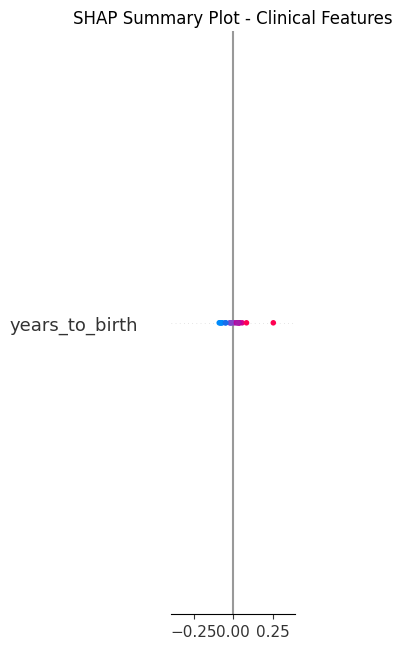

In [ ]:
# ============================================================
# CLINICAL SHAP SUMMARY PLOT
# ============================================================


plt.figure(figsize=(10,6))


shap.summary_plot(
    clinical_shap_values,
    clinical_explain_df,
    feature_names=clinical_columns,
    show=False
)


plt.title(
    "SHAP Summary Plot - Clinical Features"
)


plt.tight_layout()


plt.savefig(
    "clinical_SHAP_summary.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


##Clinical SHAP Bar Importance

/tmp/ipykernel_29606/1504912926.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 800x600 with 0 Axes>

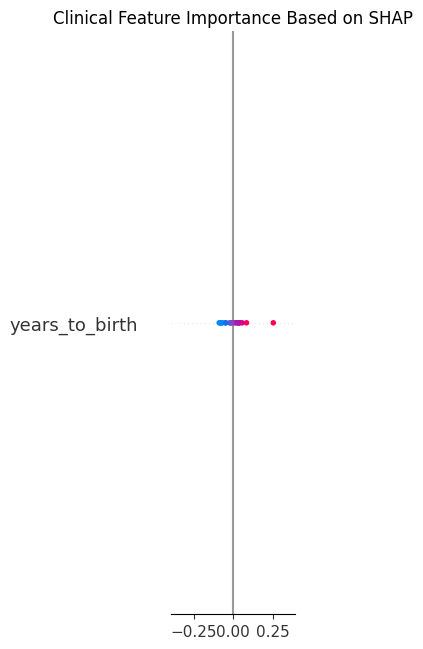

In [ ]:
# ============================================================
# CLINICAL SHAP BAR IMPORTANCE
# ============================================================


plt.figure(figsize=(8,6))


shap.summary_plot(
    clinical_shap_values,
    clinical_explain_df,
    plot_type="bar",
    show=False
)


plt.title(
    "Clinical Feature Importance Based on SHAP"
)


plt.tight_layout()


plt.savefig(
    "clinical_SHAP_importance.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

##Top Features Table

In [ ]:
# ============================================================
# TOP CLINICAL SHAP FEATURES
# ============================================================


# Remove output dimension
# (samples, features, 1) -> (samples, features)

clinical_shap_values_2d = clinical_shap_values[:,:,0]



importance = np.abs(
    clinical_shap_values_2d
).mean(axis=0)



shap_importance_df = pd.DataFrame({

    "Feature": clinical_columns,

    "Mean |SHAP|": importance

})



shap_importance_df = shap_importance_df.sort_values(
    "Mean |SHAP|",
    ascending=False
)



print("="*70)
print("TOP CLINICAL SHAP FEATURES")
print("="*70)


display(
    shap_importance_df.head(10)
)

TOP CLINICAL SHAP FEATURES


,Feature,Mean |SHAP|
6,number_of_lymph_nodes,0.076002
0,years_to_birth,0.055525
7,radiation_therapy,0.045551
15,PAM50_LumA,0.036807
3,pathology_T_stage,0.021908
1,Tumor_purity,0.016097
17,race_blackorafricanamerican,0.012634
4,pathology_N_stage,0.011944
11,histological_type_mixedhistology(pleasespecify),0.010730
2,pathologic_stage,0.010518



##Genomic SHAP Wrapper Class

In [ ]:
# ============================================================
# GENOMIC SHAP WRAPPER
# ============================================================

import torch
import torch.nn as nn


class GenomicSHAPWrapper(nn.Module):

    def __init__(
        self,
        model,
        fixed_clinical,
        fixed_pathology,
        fixed_mask
    ):

        super().__init__()

        self.model = model

        self.fixed_clinical = fixed_clinical
        self.fixed_pathology = fixed_pathology
        self.fixed_mask = fixed_mask



    def forward(self, genomic):


        batch_size = genomic.size(0)


        clinical = self.fixed_clinical

        pathology = self.fixed_pathology

        mask = self.fixed_mask



        if clinical.size(0) != batch_size:

            repeat_factor = (
                batch_size // clinical.size(0)
            ) + 1


            clinical = clinical.repeat(
                repeat_factor,
                1
            )[:batch_size]


            pathology = pathology.repeat(
                repeat_factor,
                1,
                1
            )[:batch_size]


            mask = mask.repeat(
                repeat_factor,
                1
            )[:batch_size]



        output = self.model(
            clinical,
            genomic,
            pathology,
            mask
        )


        risk = output["survival"]


        if risk.dim() == 1:
            risk = risk.unsqueeze(1)


        return risk

##Prepare Fixed Inputs

In [ ]:
# ============================================================
# FIX NON-GENOMIC INPUTS FOR GENOMIC SHAP
# ============================================================


NUM_BACKGROUND = 20


fixed_clinical_genomic = background["clinical"][:NUM_BACKGROUND]

fixed_pathology_genomic = background["pathology"][:NUM_BACKGROUND]

fixed_mask_genomic = background["mask"][:NUM_BACKGROUND]

fixed_genomic = background["genomic"][:NUM_BACKGROUND]



print("="*70)
print("FIXED GENOMIC SHAP BACKGROUND")
print("="*70)


print("Clinical :", fixed_clinical_genomic.shape)

print("Genomic :", fixed_genomic.shape)

print("Pathology :", fixed_pathology_genomic.shape)

print("Mask :", fixed_mask_genomic.shape)

FIXED GENOMIC SHAP BACKGROUND
Clinical : torch.Size([20, 20])
Genomic : torch.Size([20, 200])
Pathology : torch.Size([20, 512, 512])
Mask : torch.Size([20, 512])


##Create Genomic SHAP Wrapper

In [ ]:
# ============================================================
# CREATE GENOMIC SHAP WRAPPER
# ============================================================


genomic_model = GenomicSHAPWrapper(
    model,
    fixed_clinical_genomic,
    fixed_pathology_genomic,
    fixed_mask_genomic
)


genomic_model = genomic_model.to(DEVICE)

genomic_model.eval()


print("="*70)
print("GENOMIC SHAP MODEL READY")
print("="*70)

GENOMIC SHAP MODEL READY


##Create Genomic Background

In [ ]:
# ============================================================
# GENOMIC BACKGROUND
# ============================================================



genomic_background = fixed_genomic

print("="*70)
print("GENOMIC BACKGROUND CREATED")
print("="*70)


print(
    genomic_background.shape
)

GENOMIC BACKGROUND CREATED
torch.Size([20, 200])


##Create SHAP Explainer

In [ ]:
# ============================================================
# CREATE GENOMIC SHAP EXPLAINER
# ============================================================


genomic_explainer = shap.GradientExplainer(
    genomic_model,
    genomic_background
)


print("="*70)
print("GENOMIC SHAP EXPLAINER CREATED")
print("="*70)


GENOMIC SHAP EXPLAINER CREATED


##Select Samples To Explain

In [ ]:
# ============================================================
# GENOMIC EXPLANATION DATA
# ============================================================


# collect genomic features from test loader

all_test_genomic = []


with torch.no_grad():

    for batch in test_loader:

        genomic = batch["genomic"]

        all_test_genomic.append(
            genomic
        )


test_genomic = torch.cat(
    all_test_genomic,
    dim=0
)



# take first 20 samples

genomic_explain = test_genomic[:20].to(DEVICE)



print("="*70)
print("GENOMIC EXPLANATION DATA CREATED")
print("="*70)


print(
    genomic_explain.shape
)

GENOMIC EXPLANATION DATA CREATED
torch.Size([20, 200])


##Debug

In [ ]:
# ============================================================
# DEBUG GENOMIC SHAP INPUTS
# ============================================================

print("="*70)
print("CHECK GENOMIC SHAP INPUT SIZES")
print("="*70)


print(
    "Fixed clinical:",
    genomic_model.fixed_clinical.shape
)


print(
    "Fixed pathology:",
    genomic_model.fixed_pathology.shape
)


print(
    "Fixed mask:",
    genomic_model.fixed_mask.shape
)


print(
    "Genomic background:",
    genomic_background.shape
)


print(
    "Genomic explain:",
    genomic_explain.shape
)

CHECK GENOMIC SHAP INPUT SIZES
Fixed clinical: torch.Size([20, 20])
Fixed pathology: torch.Size([20, 512, 512])
Fixed mask: torch.Size([20, 512])
Genomic background: torch.Size([20, 200])
Genomic explain: torch.Size([20, 200])


##Compute Genomic SHAP Values

In [ ]:
# ============================================================
# COMPUTE GENOMIC SHAP VALUES
# ============================================================


genomic_shap_values = genomic_explainer.shap_values(
    genomic_explain
)



print("="*70)
print("GENOMIC SHAP VALUES COMPUTED")
print("="*70)


print(
    type(genomic_shap_values)
)


print(
    np.array(genomic_shap_values).shape
)

GENOMIC SHAP VALUES COMPUTED
<class 'numpy.ndarray'>
(20, 200, 1)


##Fix SHAP Dimensions

In [ ]:
# ============================================================
# FIX SHAP DIMENSIONS
# ============================================================


if genomic_shap_values.ndim == 3:

    genomic_shap_values = np.squeeze(
        genomic_shap_values,
        axis=-1
    )


print(
    genomic_shap_values.shape
)

(20, 200)


##Create Genomic SHAP DataFrame

In [ ]:
# ============================================================
# GENOMIC SHAP DATAFRAME
# ============================================================


genomic_explain_df = pd.DataFrame(
    genomic_explain.cpu().numpy(),
    columns=genomic_columns
)



genomic_shap_df = pd.DataFrame(
    genomic_shap_values,
    columns=genomic_columns
)



print("="*70)
print("GENOMIC SHAP DATAFRAMES CREATED")
print("="*70)



print(
    genomic_explain_df.head()
)


print(
    genomic_shap_df.head()
)

GENOMIC SHAP DATAFRAMES CREATED
     MYBPC1   ZNF385B     ALG1L    PCDH10      FLT3    PCDHA6     SPDYC  \
0 -0.916208  1.185913 -0.480355 -0.260129  1.027594 -0.291190 -0.679319   
1 -0.903679 -0.281760  0.510291  0.425344  1.549230  1.379939 -0.679319   
2  0.831635 -0.820461 -0.049294 -1.190244  1.271198  1.219804  1.276101   
3 -0.622619  0.278118  1.422092 -0.145436  0.826143  0.111483 -0.679319   
4 -0.621674 -0.644808  2.068660 -1.190244  1.475129 -2.104274 -0.679319   

    CACNA1H     PYDC1    TSPAN8  ...    SCNN1G      ZIC5     PTGDS     KCNK1  \
0  1.132295  1.450032  0.697910  ... -0.844439  1.315885  0.890177  1.235848   
1 -0.233733 -0.967601 -0.476020  ...  1.280311 -0.599734 -0.369762 -1.129390   
2 -1.058897 -0.099124 -0.350008  ...  0.159041  1.384708  0.344174  0.854044   
3 -0.014308 -1.126845 -0.248517  ... -0.295365 -0.086418  0.001096  0.054419   
4 -0.067556  1.158589  1.497665  ...  1.666959 -0.599734  0.319928 -0.118612   

     HAPLN1    RNF183  LOC96610   TM

##Top Genomic Features

In [ ]:
# ============================================================
# TOP GENOMIC SHAP FEATURES
# ============================================================


genomic_importance = np.abs(
    genomic_shap_values
).mean(axis=0)



genomic_importance_df = pd.DataFrame({

    "Feature": genomic_columns,

    "Mean |SHAP|": genomic_importance

})



genomic_importance_df = genomic_importance_df.sort_values(
    "Mean |SHAP|",
    ascending=False
)



print("="*70)
print("TOP GENOMIC SHAP FEATURES")
print("="*70)



display(
    genomic_importance_df.head(20)
)

TOP GENOMIC SHAP FEATURES


,Feature,Mean |SHAP|
28,CACNG1,0.071585
34,CYP24A1,0.068483
135,RPS28,0.059510
18,ORM1,0.057341
5,PCDHA6,0.056837
154,SRPK3,0.055693
25,LTF,0.054875
107,GATA4,0.050493
33,CACNG4,0.050370
121,PCDHGB5,0.049525


##Plot Top 20 Genomic Features

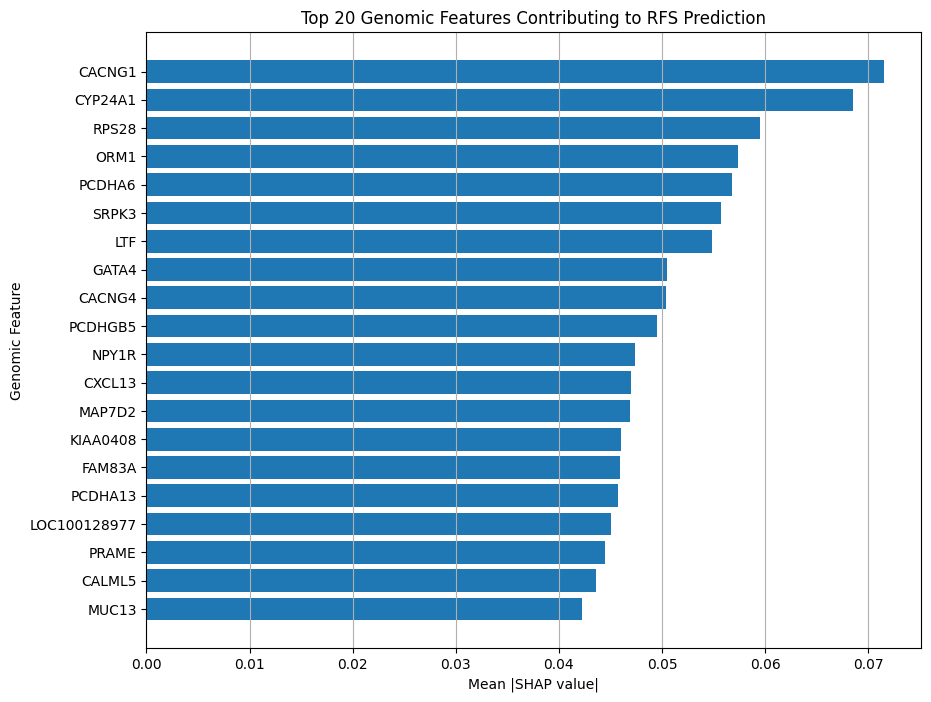

In [ ]:
# ============================================================
# GENOMIC SHAP IMPORTANCE PLOT
# ============================================================


top20 = genomic_importance_df.head(20)


plt.figure(figsize=(10,8))


plt.barh(
    top20["Feature"][::-1],
    top20["Mean |SHAP|"][::-1]
)


plt.xlabel(
    "Mean |SHAP value|"
)


plt.ylabel(
    "Genomic Feature"
)


plt.title(
    "Top 20 Genomic Features Contributing to RFS Prediction"
)


plt.grid(
    axis="x"
)


plt.show()

##Transformer Attention Analysis

##Create Attention Extraction Layer

In [ ]:
# ============================================================
# ATTENTION EXTRACTION TRANSFORMER
# ============================================================


class AttentionFusionTransformer(nn.Module):

    def __init__(
        self,
        embed_dim,
        num_heads,
        num_layers,
        dropout=0.3
    ):
        super().__init__()


        self.layers = nn.ModuleList()


        for _ in range(num_layers):

            self.layers.append(
                nn.MultiheadAttention(
                    embed_dim,
                    num_heads,
                    dropout=dropout,
                    batch_first=True
                )
            )


        self.norm = nn.LayerNorm(embed_dim)


        self.attention_weights = None



    def forward(
        self,
        clinical_token,
        genomic_token,
        pathology_token
    ):


        x = torch.cat(
            [
                clinical_token,
                genomic_token,
                pathology_token
            ],
            dim=1
        )


        for attn in self.layers:

            x, weights = attn(
                x,
                x,
                x,
                need_weights=True,
                average_attn_weights=False
            )


            self.attention_weights = weights



        x = self.norm(x)


        x = x.mean(dim=1)


        return x

##Replace Fusion With Attention Version

In [ ]:
# ============================================================
# CREATE ATTENTION MODEL
# ============================================================


attention_model = MultimodalTransformer(
    MODEL_CONFIG
)


attention_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=DEVICE
    )
)


attention_model = attention_model.to(DEVICE)

attention_model.eval()


print("="*70)
print("ATTENTION MODEL READY")
print("="*70)

ATTENTION MODEL READY


##Replace Fusion Module

In [ ]:
attention_model.fusion = AttentionFusionTransformer(
    MODEL_CONFIG["embed_dim"],
    MODEL_CONFIG["num_heads"],
    MODEL_CONFIG["num_layers"],
    MODEL_CONFIG["dropout"]
)


print("Fusion replaced with attention extractor")

Fusion replaced with attention extractor


##Get One Patient

In [ ]:
# ============================================================
# SELECT PATIENT FOR ATTENTION
# ============================================================


batch = next(iter(test_loader))


clinical = batch["clinical"].to(DEVICE)

genomic = batch["genomic"].to(DEVICE)

pathology = batch["pathology"].to(DEVICE)

mask = batch["mask"].to(DEVICE)



print(clinical.shape)
print(genomic.shape)
print(pathology.shape)

torch.Size([4, 20])
torch.Size([4, 200])
torch.Size([4, 512, 512])


##Run Attention

In [ ]:
# ============================================================
# EXTRACT ATTENTION
# ============================================================


with torch.no_grad():

    output = attention_model(
        clinical,
        genomic,
        pathology,
        mask
    )


attention_weights = (
    attention_model.fusion.attention_weights
)



print("="*70)
print("ATTENTION EXTRACTED")
print("="*70)


print(
    attention_weights.shape
)

ATTENTION EXTRACTED
torch.Size([4, 4, 3, 3])


##Average Attention

In [ ]:
# ============================================================
# AVERAGE ATTENTION
# ============================================================


attention_matrix = attention_weights.mean(
    dim=1
)


attention_matrix = attention_matrix.mean(
    dim=0
)


print(attention_matrix)

tensor([[0.1799, 0.2348, 0.3862],
        [0.2983, 0.2947, 0.2079],
        [0.3257, 0.2695, 0.3860]])


##Plot Modality Attention

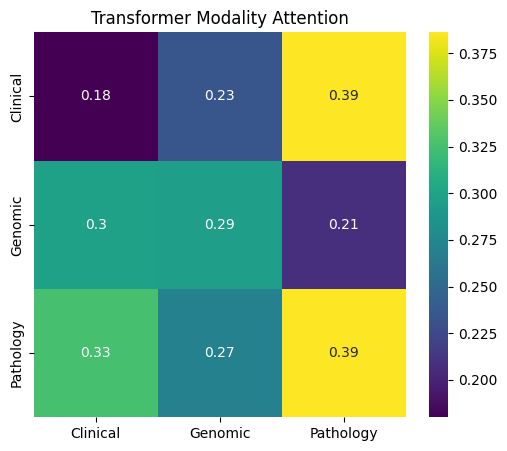

In [ ]:
# ============================================================
# MODALITY ATTENTION HEATMAP
# ============================================================


import seaborn as sns


modalities = [
    "Clinical",
    "Genomic",
    "Pathology"
]


plt.figure(
    figsize=(6,5)
)


sns.heatmap(
    attention_matrix.cpu().numpy(),
    annot=True,
    xticklabels=modalities,
    yticklabels=modalities,
    cmap="viridis"
)


plt.title(
    "Transformer Modality Attention"
)


plt.show()

##Pathology Attention Visualization

##Create Pathology Attention Extractor

In [ ]:
# ============================================================
# PATHOLOGY ATTENTION EXTRACTOR
# ============================================================


class PathologyAttentionExtractor(nn.Module):

    def __init__(self, pathology_encoder):

        super().__init__()

        self.pathology_encoder = pathology_encoder


    def forward(self, x, mask=None):

        """
        x:
        [batch, patches, 512]

        output:
        patch embeddings + attention weights
        """


        batch_size = x.size(0)


        # project patches

        x = self.pathology_encoder.patch_projection(x)


        # add CLS token

        cls_tokens = self.pathology_encoder.cls_token.expand(
            batch_size,
            -1,
            -1
        )


        x = torch.cat(
            [
                cls_tokens,
                x
            ],
            dim=1
        )


        # ---------------------------------
        # manually extract attention
        # ---------------------------------

        attention_weights = []


        for layer in self.pathology_encoder.transformer.layers:


            attn_output, attn = layer.self_attn(
                x,
                x,
                x,
                need_weights=True,
                average_attn_weights=False
            )


            attention_weights.append(
                attn
            )


            x = layer.norm1(
                x + attn_output
            )


            x = layer.norm2(
                x + layer.linear2(
                    layer.dropout(
                        layer.activation(
                            layer.linear1(x)
                        )
                    )
                )
            )


        x = self.pathology_encoder.norm(x)


        return x, attention_weights



print("="*70)
print("PATHOLOGY ATTENTION EXTRACTOR CREATED")
print("="*70)

PATHOLOGY ATTENTION EXTRACTOR CREATED


##Create Attention Model

In [ ]:
# ============================================================
# CREATE PATHOLOGY ATTENTION MODEL
# ============================================================


pathology_attention_model = PathologyAttentionExtractor(
    model.pathology_encoder
)


pathology_attention_model = pathology_attention_model.to(
    DEVICE
)


pathology_attention_model.eval()


print("="*70)
print("PATHOLOGY ATTENTION MODEL READY")
print("="*70)

PATHOLOGY ATTENTION MODEL READY


##Get One Patient Pathology Data

In [ ]:
# ============================================================
# SELECT PATIENT PATHOLOGY
# ============================================================


batch = next(iter(test_loader))


pathology = batch["pathology"].to(
    DEVICE
)


mask = batch["mask"].to(
    DEVICE
)


print("="*70)
print("PATHOLOGY SAMPLE")
print("="*70)


print(
    "Pathology:",
    pathology.shape
)


print(
    "Mask:",
    mask.shape
)

PATHOLOGY SAMPLE
Pathology: torch.Size([4, 512, 512])
Mask: torch.Size([4, 512])


##Extract Patch Attention

In [ ]:
# ============================================================
# EXTRACT PATHOLOGY ATTENTION
# ============================================================


with torch.no_grad():

    encoded, attention_weights = pathology_attention_model(
        pathology,
        mask
    )


print("="*70)
print("PATHOLOGY ATTENTION EXTRACTED")
print("="*70)


print(
    "Encoded:",
    encoded.shape
)


print(
    "Number of layers:",
    len(attention_weights)
)


print(
    "Attention shape:",
    attention_weights[0].shape
)

PATHOLOGY ATTENTION EXTRACTED
Encoded: torch.Size([4, 513, 128])
Number of layers: 2
Attention shape: torch.Size([4, 4, 513, 513])


##Extract Patch Importance Scores

In [ ]:
# ============================================================
# COMPUTE PATCH IMPORTANCE
# ============================================================


# use last transformer layer

last_attention = attention_weights[-1]


# average heads

attention_mean = last_attention.mean(
    dim=1
)


# CLS token attention to patches

patch_attention = attention_mean[:,0,1:]


print("="*70)
print("PATCH ATTENTION SCORES")
print("="*70)


print(
    patch_attention.shape
)

PATCH ATTENTION SCORES
torch.Size([4, 512])


##Rank Important Patches

In [ ]:
# ============================================================
# TOP IMPORTANT PATCHES
# ============================================================


patient_id = 0


scores = patch_attention[
    patient_id
]


top_k = 20


top_values, top_indices = torch.topk(
    scores,
    k=top_k
)


print("="*70)
print("TOP PATHOLOGY PATCHES")
print("="*70)


for i in range(top_k):

    print(
        f"Patch {top_indices[i].item()}",
        "Attention:",
        round(
            top_values[i].item(),
            4
        )
    )

TOP PATHOLOGY PATCHES
Patch 158 Attention: 0.0031
Patch 104 Attention: 0.0031
Patch 186 Attention: 0.0028
Patch 436 Attention: 0.0027
Patch 265 Attention: 0.0027
Patch 187 Attention: 0.0027
Patch 379 Attention: 0.0026
Patch 391 Attention: 0.0026
Patch 253 Attention: 0.0025
Patch 260 Attention: 0.0025
Patch 168 Attention: 0.0025
Patch 61 Attention: 0.0025
Patch 506 Attention: 0.0025
Patch 123 Attention: 0.0025
Patch 170 Attention: 0.0025
Patch 198 Attention: 0.0025
Patch 105 Attention: 0.0025
Patch 435 Attention: 0.0025
Patch 70 Attention: 0.0024
Patch 223 Attention: 0.0024


##Visualize Attention Distribution

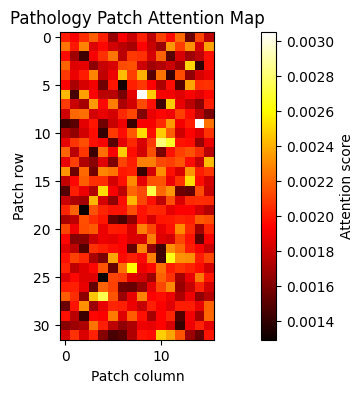

In [ ]:
# ============================================================
# PATHOLOGY ATTENTION HEATMAP
# ============================================================


plt.figure(
    figsize=(12,4)
)


plt.imshow(
    scores.cpu().numpy().reshape(32,16),
    cmap="hot"
)


plt.colorbar(
    label="Attention score"
)


plt.title(
    "Pathology Patch Attention Map"
)


plt.xlabel(
    "Patch column"
)


plt.ylabel(
    "Patch row"
)


plt.show()


# ============================================================
# SAVE EXPLAINABILITY RESULTS - VERSION 1
# ============================================================


In [ ]:
# ============================================================
# CREATE EXPLAINABILITY RESULTS FOLDER
# ============================================================

import os

EXPLAIN_DIR = "/content/drive/MyDrive/TCGA_BRCA/explainability_results_v1"

os.makedirs(
    EXPLAIN_DIR,
    exist_ok=True
)


print("="*70)
print("SAVE DIRECTORY CREATED")
print("="*70)

print(EXPLAIN_DIR)

SAVE DIRECTORY CREATED
/content/drive/MyDrive/TCGA_BRCA/explainability_results_v1


In [ ]:
# ============================================================
# SAVE CLINICAL SHAP IMPORTANCE
# ============================================================

clinical_shap_path = os.path.join(
    EXPLAIN_DIR,
    "clinical_SHAP_feature_importance.csv"
)


shap_importance_df.to_csv(
    clinical_shap_path,
    index=False
)


print("Saved:")
print(clinical_shap_path)

Saved:
/content/drive/MyDrive/TCGA_BRCA/explainability_results_v1/clinical_SHAP_feature_importance.csv


In [ ]:
# ============================================================
# CREATE GENOMIC SHAP IMPORTANCE TABLE
# ============================================================


# Remove extra output dimension if exists
genomic_shap_array = np.array(
    genomic_shap_values
)


print("Original SHAP shape:")
print(genomic_shap_array.shape)



if genomic_shap_array.ndim == 3:

    genomic_shap_array = genomic_shap_array.squeeze(-1)



print("Processed SHAP shape:")
print(genomic_shap_array.shape)



# Mean absolute SHAP importance

genomic_importance = np.abs(
    genomic_shap_array
).mean(axis=0)



genomic_shap_importance_df = pd.DataFrame({

    "Feature":
    genomic_columns,

    "Mean |SHAP|":
    genomic_importance

})



genomic_shap_importance_df = genomic_shap_importance_df.sort_values(
    "Mean |SHAP|",
    ascending=False
)



print("="*70)
print("TOP GENOMIC SHAP FEATURES")
print("="*70)


display(
    genomic_shap_importance_df.head(20)
)

Original SHAP shape:
(20, 200)
Processed SHAP shape:
(20, 200)
TOP GENOMIC SHAP FEATURES


,Feature,Mean |SHAP|
28,CACNG1,0.071585
34,CYP24A1,0.068483
135,RPS28,0.059510
18,ORM1,0.057341
5,PCDHA6,0.056837
154,SRPK3,0.055693
25,LTF,0.054875
107,GATA4,0.050493
33,CACNG4,0.050370
121,PCDHGB5,0.049525


In [ ]:
# ============================================================
# SAVE GENOMIC SHAP IMPORTANCE
# ============================================================


genomic_shap_path = os.path.join(
    EXPLAIN_DIR,
    "genomic_SHAP_feature_importance.csv"
)


genomic_shap_importance_df.to_csv(
    genomic_shap_path,
    index=False
)


print("Saved:")
print(genomic_shap_path)

Saved:
/content/drive/MyDrive/TCGA_BRCA/explainability_results_v1/genomic_SHAP_feature_importance.csv


In [ ]:
plt.savefig(
    os.path.join(
        EXPLAIN_DIR,
        "clinical_SHAP_barplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    os.path.join(
        EXPLAIN_DIR,
        "clinical_SHAP_barplot.pdf"
    ),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(
        EXPLAIN_DIR,
        "genomic_SHAP_barplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# CHECK ATTENTION VARIABLES
# ============================================================

for name in dir():

    if "attention" in name.lower():

        print(name)

AttentionFusionTransformer
PathologyAttentionExtractor
attention_matrix
attention_mean
attention_model
attention_weights
last_attention
patch_attention
pathology_attention_model


In [ ]:
print(type(attention_weights))

print(len(attention_weights))

print(type(attention_weights[0]))

print(attention_weights[0].shape)

<class 'list'>
2
<class 'torch.Tensor'>
torch.Size([4, 4, 513, 513])


In [ ]:
# ============================================================
# PREPARE MODALITY ATTENTION MATRIX
# ============================================================


# combine transformer layers

attention_tensor = torch.stack(
    attention_weights
)


print("Stacked attention:")
print(attention_tensor.shape)



# Average:
# layers
# samples
# heads

modality_attention = attention_tensor.mean(
    dim=(0,1,2)
)


print("="*70)
print("MODALITY ATTENTION CREATED")
print("="*70)


print(
    modality_attention.shape
)

Stacked attention:
torch.Size([2, 4, 4, 513, 513])
MODALITY ATTENTION CREATED
torch.Size([513, 513])


In [ ]:
# ============================================================
# SAVE PATHOLOGY PATCH ATTENTION
# ============================================================


pathology_attention_matrix = patch_attention[0].detach().cpu().numpy()


print("="*70)
print("PATHOLOGY ATTENTION MATRIX")
print("="*70)

print(
    pathology_attention_matrix.shape
)

PATHOLOGY ATTENTION MATRIX
(512,)


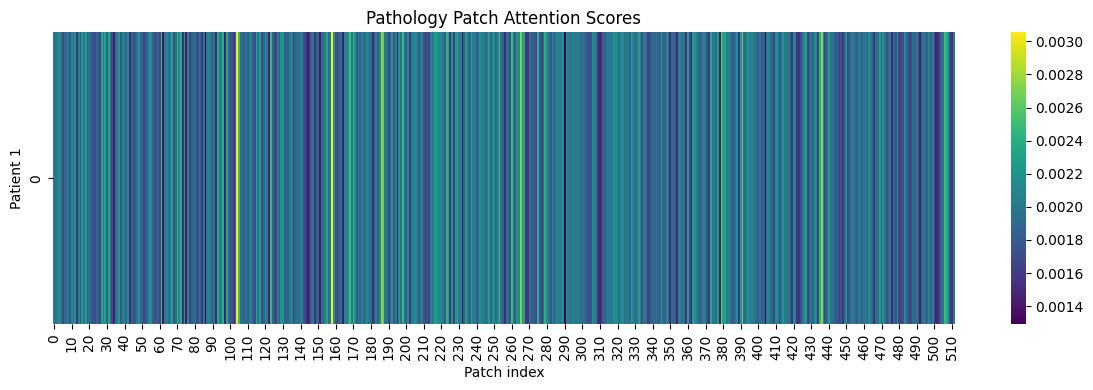

In [ ]:
import seaborn as sns


plt.figure(figsize=(12,4))


sns.heatmap(
    pathology_attention_matrix.reshape(1,-1),
    cmap="viridis",
    cbar=True
)


plt.xlabel(
    "Patch index"
)

plt.ylabel(
    "Patient 1"
)


plt.title(
    "Pathology Patch Attention Scores"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        EXPLAIN_DIR,
        "pathology_patch_attention_heatmap.png"
    ),
    dpi=300
)


plt.show()

In [ ]:
# ============================================================
# SAVE TOP PATHOLOGY PATCHES
# ============================================================


top_k = 20


scores = patch_attention[0].detach().cpu().numpy()


top_indices = np.argsort(
    scores
)[::-1][:top_k]


top_patch_df = pd.DataFrame({

    "Patch_Index":
    top_indices,


    "Attention_Score":
    scores[top_indices]

})


top_patch_path = os.path.join(
    EXPLAIN_DIR,
    "top_pathology_attention_patches.csv"
)


top_patch_df.to_csv(
    top_patch_path,
    index=False
)


print("="*70)
print("TOP PATHOLOGY PATCH TABLE SAVED")
print("="*70)


display(
    top_patch_df
)

TOP PATHOLOGY PATCH TABLE SAVED


,Patch_Index,Attention_Score
0,158,0.003054
1,104,0.003052
2,186,0.002809
3,436,0.002740
4,265,0.002730
5,187,0.002674
6,379,0.002646
7,391,0.002604
8,253,0.002524
9,260,0.002522


In [ ]:
# ============================================================
# SAVE PATHOLOGY PATCH ATTENTION TABLE
# ============================================================


top_k = 20


# Select first patient attention scores
values = patch_attention[0]


# Get highest attention patches
top_indices = torch.argsort(
    values,
    descending=True
)[:top_k]


# Create dataframe
pathology_attention_df = pd.DataFrame({

    "Patch_Index":
    top_indices.detach().cpu().numpy(),

    "Attention_Score":
    values[top_indices].detach().cpu().numpy()

})


# Save CSV

pathology_attention_path = os.path.join(
    EXPLAIN_DIR,
    "pathology_top_patch_attention.csv"
)


pathology_attention_df.to_csv(
    pathology_attention_path,
    index=False
)


print("="*70)
print("PATHOLOGY PATCH ATTENTION TABLE SAVED")
print("="*70)

print(
    pathology_attention_path
)


display(
    pathology_attention_df
)

PATHOLOGY PATCH ATTENTION TABLE SAVED
/content/drive/MyDrive/TCGA_BRCA/explainability_results_v1/pathology_top_patch_attention.csv


,Patch_Index,Attention_Score
0,158,0.003054
1,104,0.003052
2,186,0.002809
3,436,0.002740
4,265,0.002730
5,187,0.002674
6,379,0.002646
7,391,0.002604
8,253,0.002524
9,260,0.002522
